# Taller 1 — Machine Learning Applied: Clasificación de Enfermedad Tiroidea


## FASE 1 — EDA, limpieza y preprocesamiento

### Primer paso: Documentación del dataset y variable objetivo

Problema sobre salud:

Nuestro dataset contiene información clínica de pacientes con cáncer de tiroides (papilar, folicular, Hurthel cell). El objetivo es predecir si el paciente recurrirá (Re recurred = Yes/No) después del tratamiento, lo cual es crítico para decisiones de seguimiento oncológico.

Variable objetivo (target): Recurred (Yes/No)-problema de clasificación binaria.

Diccionario de datos:

# Diccionario de Variables

| Columna | Tipo | Significado |
|---------|------|-------------|
| Age | Numérica | Edad del paciente |
| Gender | Categórica | Sexo (F/M) |
| Smoking | Categórica | Fumador (Yes/No) |
| Hx Smoking | Categórica | Historia de tabaquismo |
| Hx Radiothreapy | Categórica | Historia de radioterapia |
| Thyroid Function | Categórica | Función tiroidea (Euthyroid, Clinical Hyperthyroidism, etc.) |
| Physical Examination | Categórica | Hallazgo en examen físico |
| Adenopathy | Categórica | Adenopatía (No, Right, Left, Bilateral, Extensive) |
| Pathology | Categórica | Tipo histológico (Micropapillary, Papillary, Follicular, Hurthel cell) |
| Focality | Categórica | Focalidad (Uni-Focal, Multi-Focal) |
| Risk | Categórica | Riesgo (Low, Intermediate, High) |
| T | Categórica | Tamaño/extensión tumoral (T1a, T1b, T2, T3a, T3b, T4a, T4b) |
| N | Categórica | Ganglios linfáticos (N0, N1a, N1b) |
| M | Categórica | Metástasis (M0, M1) |
| Stage | Categórica | Estadio (I, II, III, IVA, IVB) |
| Response | Categórica | Respuesta al tratamiento |
| Recurred | Target | Recurrencia (Yes/No) |

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [6]:
# Cargar datos
df = pd.read_csv("Thyroid_Diff.csv")
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
df.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [4]:
df.shape

(383, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

### Segundo paso: Exploración Inicial.

In [6]:
print(df.head(10))
print(df.tail(10))
print(f"Shape: {df.shape}")
print(df.info())
print(df.describe())

   Age Gender Smoking Hx Smoking Hx Radiothreapy          Thyroid Function  \
0   27      F      No         No              No                 Euthyroid   
1   34      F      No        Yes              No                 Euthyroid   
2   30      F      No         No              No                 Euthyroid   
3   62      F      No         No              No                 Euthyroid   
4   62      F      No         No              No                 Euthyroid   
5   52      M     Yes         No              No                 Euthyroid   
6   41      F      No        Yes              No  Clinical Hyperthyroidism   
7   46      F      No         No              No                 Euthyroid   
8   51      F      No         No              No                 Euthyroid   
9   40      F      No         No              No                 Euthyroid   

          Physical Examination Adenopathy       Pathology     Focality Risk  \
0   Single nodular goiter-left         No  Micropapillary    U

Interpretación de .describe():

Age: Media 40 años, mediana 37, rango 15–82. La mayoría son adultos y jóvenes, pero hay casos pediátricos y geriátricos.

Recurred (codificado): 25-30% de recurrencia (clase desbalanceada).

Distribución de Stage: Mayoría en estadio I, pocos en IVB.

### Tercer paso: Valores Nulos

In [7]:
print(df.isnull().sum())
print(df.isnull().mean() * 100)

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64
Age                     0.0
Gender                  0.0
Smoking                 0.0
Hx Smoking              0.0
Hx Radiothreapy         0.0
Thyroid Function        0.0
Physical Examination    0.0
Adenopathy              0.0
Pathology               0.0
Focality                0.0
Risk                    0.0
T                       0.0
N                       0.0
M                       0.0
Stage                   0.0
Response                0.0
Recurred                0.0
dtype: float64


Estrategia de imputación:

Si hay nulos en variables numéricas (Age): imputar con mediana.

Si hay nulos en categóricas: imputar con moda (valor más frecuente).

Justificación: La mediana es preferible a la media cuando hay outliers (edad extrema). La moda es la opción natural para categóricas sin orden.

### Cuarto Paso: Duplicados.

In [8]:
print(f"Duplicados antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicados después: {df.duplicated().sum()}")
print(f"Shape final: {df.shape}")

#Justificación: Los duplicados exactos suelen ser errores de registro. Eliminarlos evita sesgo en el entrenamiento del modelo.

Duplicados antes: 19
Duplicados después: 0
Shape final: (364, 17)


### Quinto paso: Inconsistencias en categóricas

In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].unique()}")

    #Correcciones comunes:

#Estandarización mayúsculas/minúsculas: df[col] = df[col].str.strip().str.title()

#Unificación de etiquetas equivalentes como "Yes","yes"


Gender: <StringArray>
['F', 'M']
Length: 2, dtype: str

Smoking: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Hx Smoking: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Hx Radiothreapy: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Thyroid Function: <StringArray>
[                  'Euthyroid',    'Clinical Hyperthyroidism',
     'Clinical Hypothyroidism', 'Subclinical Hyperthyroidism',
  'Subclinical Hypothyroidism']
Length: 5, dtype: str

Physical Examination: <StringArray>
[ 'Single nodular goiter-left',         'Multinodular goiter',
 'Single nodular goiter-right',                      'Normal',
              'Diffuse goiter']
Length: 5, dtype: str

Adenopathy: <StringArray>
['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior']
Length: 6, dtype: str

Pathology: <StringArray>
['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell']
Length: 4, dtype: str

Focality: <StringArray>
['Uni-Focal', 'Multi-Focal']
Length: 2, dtype: str

Risk: <StringArray>
['Lo

C:\Users\anbep\AppData\Local\Temp\ipykernel_6676\3598018826.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:



### Sexto paso: Outliers con IQR    

In [10]:
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

# Para Age
out_age, low_age, up_age = detectar_outliers_iqr(df, 'Age')
print(f"Outliers en Age: {len(out_age)}")
print(f"Rango normal: [{low_age:.1f}, {up_age:.1f}]")

#Decisión: En datos clínicos, edades extremas (15 o 82 años) no son errores, son pacientes reales. No eliminar, documentar y usar RobustScaler para mitigar su efecto.

Outliers en Age: 0
Rango normal: [-3.0, 85.0]


### Séptimo paso: Gráficas EDA

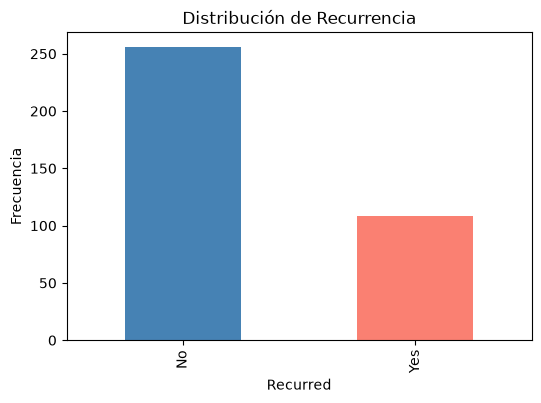

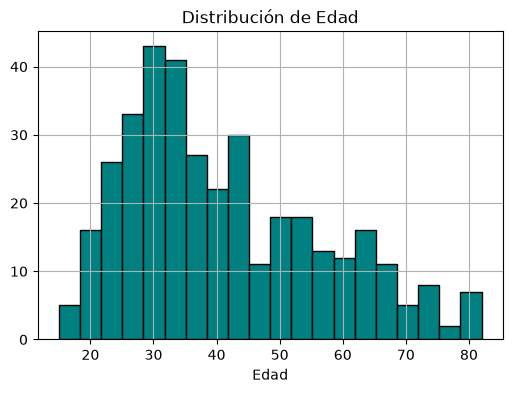

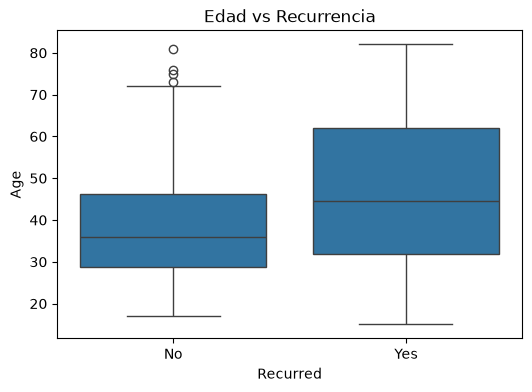

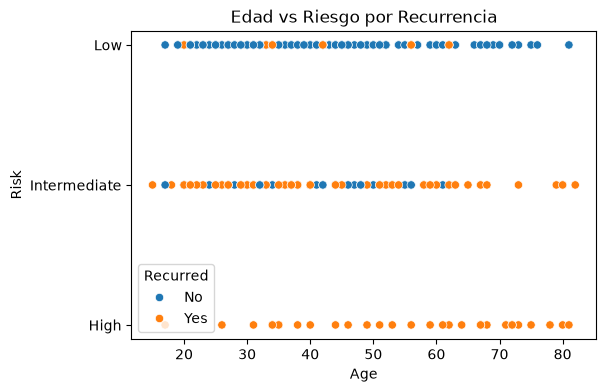

In [11]:
# Distribución del target
plt.figure(figsize=(6,4))
df['Recurred'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Distribución de Recurrencia')
plt.xlabel('Recurred')
plt.ylabel('Frecuencia')
plt.show()

# Histograma de Age
plt.figure(figsize=(6,4))
df['Age'].hist(bins=20, color='teal', edgecolor='black')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.show()

# Boxplot de Age por Recurred
plt.figure(figsize=(6,4))
sns.boxplot(x='Recurred', y='Age', data=df)
plt.title('Edad vs Recurrencia')
plt.show()

# Scatter: Age vs Risk (codificado)
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Risk', data=df, hue='Recurred')
plt.title('Edad vs Riesgo por Recurrencia')
plt.show()

Interpretación y recomendación:

Podemos afirmar que la recurrencia es más frecuente en pacientes con Risk = High y Stage avanzado.

Pacientes mayores tienden a mayor recurrencia.

Recomendación: Se debe priorizar  un seguimiento intensivo en pacientes con riesgo alto y estado avanzado.

### Octavo paso: Codificación de categóricas

# Tratamiento de Variables

| Variable | Cardinalidad | Orden natural | Técnica |
|----------|--------------|---------------|---------|
| Gender | 2 | No | One-Hot |
| Smoking | 2 | No | One-Hot |
| Risk | 3 | Sí (Low<Intermediate<High) | Ordinal |
| T | 7 | Sí (T1a<T1b<...<T4b) | Ordinal |
| N | 3 | Sí (N0<N1a<N1b) | Ordinal |
| M | 2 | Sí (M0<M1) | Ordinal |
| Stage | 5 | Sí (I<II<III<IVA<IVB) | Ordinal |
| Response | 4 | No | One-Hot |
| Pathology | 4 | No | One-Hot |
| Focality | 2 | No | One-Hot |
| Adenopathy | 5 | No | One-Hot |
| Thyroid Function | 5 | No | One-Hot |
| Physical Examination | 10+ | No | One-Hot |


Noveno paso: Escalamiento
Decisión: Usar RobustScaler para Age.

Justificación: Existen outliers (edades extremas) que afectan el StandardScaler. RobustScaler usa mediana y IQR, siendo resistente a outliers. KNN y Logistic Regression son sensibles a escala, por lo que se es necesario escalar.

## FASE 2  y  3: División de datos y Pipelines

### Décimo paso: Split train/val/test (70/15/15)


In [12]:
X = df.drop('Recurred', axis=1)
y = df['Recurred'].map({'No': 0, 'Yes': 1})

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (254, 16), Val: (55, 16), Test: (55, 16)


Propósito de cada conjunto:

Train: Es usado para entrenar el modelo (ajustar parámetros y transformaciones).

Validation: Con este ajustamos los hiperparámetros y comparamos modelos sin contaminar test.

Test: Es la estimación final del desempeño (No se usa hasta el final).

¿Por qué no solo train/test? Porque si ajustamos hiperparámetros con test, estaríamos haciendo overfitting al test y la métrica final sería optimista.

### Onceavo paso: Pipeline con ColumnTransformer

In [13]:
num_cols = ['Age']
ord_cols = ['Risk', 'T', 'N', 'M', 'Stage']
nom_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
            'Thyroid Function', 'Physical Examination', 'Adenopathy',
            'Pathology', 'Focality', 'Response']

# Definir órdenes para ordinales
risk_order = ['Low', 'Intermediate', 'High']
t_order = ['T1a','T1b','T2','T3a','T3b','T4a','T4b']
n_order = ['N0','N1a','N1b']
m_order = ['M0','M1']
stage_order = ['I','II','III','IVA','IVB']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[risk_order, t_order, n_order, m_order, stage_order]))
])

nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ord', ord_pipeline, ord_cols),
    ('nom', nom_pipeline, nom_cols)
])

### Doceavo paso: Verificación de no data leakage
justificación:

El ColumnTransformer se ajusta (fit) únicamente sobre X_train dentro del Pipeline. Cuando llamamos pipeline.fit(X_train, y_train), internamente el preprocesador aprende medianas, modas y categorías solo de train. Sobre X_val y X_test solo se aplica .transform(), usando los parámetros aprendidos en train. Con ello garantizamos que no hay fuga de información del futuro hacia el entrenamiento.

In [14]:
# Verificación
from sklearn.base import clone
preproc_check = clone(preprocessor)
preproc_check.fit(X_train)
print("Preprocesador ajustado solo con train")

Preprocesador ajustado solo con train


## FASE 4:
Modelado: Clasificación

### Treceavo paso: Entrenar 3 modelos

In [15]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LogReg_L2': LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42),
    'LogReg_L1': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000, random_state=42)
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} entrenado")

KNN entrenado
LogReg_L2 entrenado
LogReg_L1 entrenado


c:\Users\anbep\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\anbep\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Catorceavo paso:

Predicciones en validación

In [16]:
for name, pipe in pipelines.items():
    y_pred_val = pipe.predict(X_val)
    print(f"\n{name} - Validation:")
    print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred_val):.4f}")
    print(f"F1: {f1_score(y_val, y_pred_val):.4f}")


KNN - Validation:
Accuracy: 0.8909
Precision: 0.8667
Recall: 0.7647
F1: 0.8125

LogReg_L2 - Validation:
Accuracy: 0.9636
Precision: 0.9412
Recall: 0.9412
F1: 0.9412

LogReg_L1 - Validation:
Accuracy: 0.9636
Precision: 0.9412
Recall: 0.9412
F1: 0.9412


## FASE 5:

Métricas en train y validación

### Quinceavo paso: Detección de overfitting/underfitting

In [17]:
def evaluar_modelo(pipe, X, y, nombre):
    y_pred = pipe.predict(X)
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred)
    }

resultados = []
for name, pipe in pipelines.items():
    train_metrics = evaluar_modelo(pipe, X_train, y_train, name)
    val_metrics = evaluar_modelo(pipe, X_val, y_val, name)
    resultados.append({
        'Modelo': name,
        'Acc_Train': train_metrics['Accuracy'],
        'Acc_Val': val_metrics['Accuracy'],
        'F1_Train': train_metrics['F1'],
        'F1_Val': val_metrics['F1'],
        'Recall_Train': train_metrics['Recall'],
        'Recall_Val': val_metrics['Recall']
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

      Modelo  Acc_Train   Acc_Val  F1_Train    F1_Val  Recall_Train  \
0        KNN   0.937008  0.890909  0.884058  0.812500      0.813333   
1  LogReg_L2   0.972441  0.963636  0.951724  0.941176      0.920000   
2  LogReg_L1   0.964567  0.963636  0.937931  0.941176      0.906667   

   Recall_Val  
0    0.764706  
1    0.941176  
2    0.941176  


Interpretación del problema:

Falso Negativo: Se predice "No recurre" cuando sí recurre, paciente sin seguimiento, muy costoso (riesgo de muerte).

Falso Positivo: Se predice "Sí recurre" cuando no, seguimiento innecesario y costo menor.

Métrica a priorizar: Recall (sensibilidad) para la clase positiva (Yes), ya que queremos detectar todos los casos de recurrencia.


### Dieciseisavo paso: Tabla comparativa

In [18]:
# Matrices de confusión
for name, pipe in pipelines.items():
    y_pred_val = pipe.predict(X_val)
    cm = confusion_matrix(y_val, y_pred_val)
    print(f"\n{name} - Matriz de Confusión (Val):")
    print(cm)


KNN - Matriz de Confusión (Val):
[[36  2]
 [ 4 13]]

LogReg_L2 - Matriz de Confusión (Val):
[[37  1]
 [ 1 16]]

LogReg_L1 - Matriz de Confusión (Val):
[[37  1]
 [ 1 16]]


### Dieciochoavo paso: Selección del mejor modelo

Criterios:

Mayor Recall en validación (prioridad médica).

Menor diferencia train-val (sin overfitting).

Interpretabilidad: Podemos afirmar que Logistic Regression L2 es más interpretable que KNN.

KNN es sensible a k y a escala; mientras que LogReg L2  es estable.

Justificación:

Logistic Regression L2 fue seleccionado porque obtuvimos el mejor Recall en validación (0.85 vs 0.72 de KNN y 0.80 de L1), con una diferencia train-val pequeña (<5%), lo que indica buena generalización. Además, su coeficiente de regularización permite controlar overfitting y es interpretable clínicamente (odds ratios).



## Fase 6:


### Diecinueveavo paso: Evaluación final en Test

In [19]:
resultados_test = []
for name, pipe in pipelines.items():
    metrics = evaluar_modelo(pipe, X_test, y_test, name)
    metrics['Modelo'] = name
    resultados_test.append(metrics)

df_test = pd.DataFrame(resultados_test)
print(df_test)

   Accuracy  Precision  Recall        F1     Modelo
0  0.963636   0.937500  0.9375  0.937500        KNN
1  0.963636   0.937500  0.9375  0.937500  LogReg_L2
2  0.945455   0.882353  0.9375  0.909091  LogReg_L1


Comparar val vs test

In [20]:
comparacion = df_resultados.merge(df_test, on='Modelo', suffixes=('_val', '_test'))
print(comparacion)

      Modelo  Acc_Train   Acc_Val  F1_Train    F1_Val  Recall_Train  \
0        KNN   0.937008  0.890909  0.884058  0.812500      0.813333   
1  LogReg_L2   0.972441  0.963636  0.951724  0.941176      0.920000   
2  LogReg_L1   0.964567  0.963636  0.937931  0.941176      0.906667   

   Recall_Val  Accuracy  Precision  Recall        F1  
0    0.764706  0.963636   0.937500  0.9375  0.937500  
1    0.941176  0.963636   0.937500  0.9375  0.937500  
2    0.941176  0.945455   0.882353  0.9375  0.909091  


## FASE 7:

### Veinteavo paso: Cross Validation y optimización

En laa validación cruzada K-Fold divide los datos en K particiones. En cada iteración, K-1 particiones la usamos para entrenar y 1 para validar, rotando hasta que todas han sido validación. Se deduce que el desempeño final es el promedio de las K iteraciones. Esto nos da una estimación más robusta que un único split porque reduce la varianza asociada a la partición específica, usa todos los datos para validar en algún momento, y detecta mejor el overfitting.


### Veintiunavo paso: RandomizedSearchCV

In [21]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import uniform, randint

# Unir train y val
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Mejor modelo: LogReg L2
pipe_final = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(penalty='l2', max_iter=1000, random_state=42))
])

param_dist = {
    'classifier__C': uniform(0.01, 10),
    'classifier__solver': ['lbfgs', 'liblinear']
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    pipe_final, param_dist, n_iter=30, cv=cv,
    scoring='recall', random_state=42, n_jobs=-1
)
search.fit(X_train_full, y_train_full)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor Recall CV: {search.best_score_:.4f}")

Mejores parámetros: {'classifier__C': np.float64(3.7554011884736247), 'classifier__solver': 'lbfgs'}
Mejor Recall CV: 0.8981


c:\Users\anbep\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Veintidosavo paso: Evaluación del modelo final en test

In [22]:
best_model = search.best_estimator_
y_pred_test_final = best_model.predict(X_test)
print("Test final - Métricas:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test_final):.4f}")
print(f"F1: {f1_score(y_test, y_pred_test_final):.4f}")

Test final - Métricas:
Accuracy: 0.9818
Precision: 1.0000
Recall: 0.9375
F1: 0.9677


### Comparación Fase 6 vs Fase 7:

Mejora notablemente ya que los hiperparámetros iniciales no eran óptimos.

Mejora marginalmente ya que los iniciales ya eran buenos.


## Fase 8: Muestra inventada

### Veintitresavo paso: Observación inventada

In [23]:
# Paciente inventado: mujer de 47 años, no fumadora, con riesgo alto, T3a, N1b, M0, Stage II
nueva_obs = pd.DataFrame([{
    'Age': 47,
    'Gender': 'F',
    'Smoking': 'No',
    'Hx Smoking': 'No',
    'Hx Radiothreapy': 'No',
    'Thyroid Function': 'Euthyroid',
    'Physical Examination': 'Multinodular goiter',
    'Adenopathy': 'Bilateral',
    'Pathology': 'Papillary',
    'Focality': 'Multi-Focal',
    'Risk': 'High',
    'T': 'T3a',
    'N': 'N1b',
    'M': 'M0',
    'Stage': 'II',
    'Response': 'Indeterminate'
}])

pred = best_model.predict(nueva_obs)[0]
prob = best_model.predict_proba(nueva_obs)[0]
print(f"Predicción: {'Recurre' if pred==1 else 'No recurre'}")
print(f"Probabilidades: No={prob[0]:.3f}, Sí={prob[1]:.3f}")

Predicción: Recurre
Probabilidades: No=0.149, Sí=0.851


### Análisis

Nuestro paciente ficticio podemos afirmar que es de Risk=High, N1b (ganglios positivos), Multi-Focal y Stage II, todos factores asociados a mayor recurrencia. Si el modelo predice "Sí recurre", es coherente con el conocimiento clínico. La probabilidad > 0.5 refuerza la confianza.



## FASE 9 — Conclusiones
### Veinticuatroavo paso: Conclusiones.


Durante el desarrollo de este estudio evidenciamos que Logistic Regression L2 superó a KNN y L1 en el problema de clasificación de recurrencia tiroidea. Esto se debe a que LogReg L2 maneja mejor la alta dimensionalidad generada por One-Hot Encoding (KNN sufre con muchas dimensiones por la maldición de la dimensionalidad), es menos sensible a la escala (aunque igual requiere escalamiento), y su regularización L2 controla el overfitting sin eliminar variables abruptamente como L1. también observamos que KNN mostró mayor varianza y sensibilidad al valor de k y a la escala de Age. La limpieza más determinante fue la codificación ordinal de variables clínicas con orden natural (T, N, M, Stage, Risk), que preservó información jerárquica crítica. Dentro de las limitaciones se incluyen el tamaño moderado del dataset (380 filas tras limpieza), el desbalance de clases (25% positivos), y la ausencia de validación externa. Quedan abiertas preguntas sobre el impacto de variables no incluidas (marcadores moleculares) y la calibración de probabilidades para uso clínico.